# STAGE 08 — PER-CORRIDOR GOOD-DAY RULES

Цель — выбрать отдельное прозрачное правило `F/A/R` для каждого коридора **только на validation**, зафиксировать его и один раз применить к locked test.

Основной ground truth `GT_B`: `favourability_percentile_90 >= 0.85 AND actual_regret_5 <= 0.005`, то есть `GOOD = ATTRACTIVE_NOW AND SAFE_TO_ACT`. Actual future используется только в labels/evaluation.

## 1. Восстановление Stage 04 validation predictions

Это разрешённое однократное воспроизведение, а не tuning: для каждой пары corridor × H1…H5 берутся сохранённые `config_id`, hyperparameters и `trees_used`; random seed, features, preprocessing и split остаются прежними. Модель обучается только на TRAIN. TEST при восстановлении и выборе thresholds не используется.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from src.per_corridor_good_day_rules import plot_test, run_stage08

required = ['reports/good_day_features.csv','reports/catboost_model_selection.csv','reports/temporal_split_horizons.csv']
inventory = pd.DataFrame({'artifact': required, 'exists': [(ROOT/p).exists() for p in required]})
display(inventory)
if not inventory.exists.all(): raise FileNotFoundError(inventory.loc[~inventory.exists,'artifact'].tolist())
run = run_stage08(ROOT, make_plots=False)

,artifact,exists
0,reports/good_day_features.csv,True
1,reports/catboost_model_selection.csv,True
2,reports/temporal_split_horizons.csv,True


In [2]:
display(run['consistency'])
print('Maximum absolute restored MAE difference:', run['consistency'].absolute_MAE_difference.max())
print('New tuning performed: NO')
print('Validation predictions:', len(run['restored']))

,corridor,horizon,config_id,trees_used,saved_MAE,restored_MAE,absolute_MAE_difference,same_config_reused,trained_on_train_only
0,AMD_RUB,1,CONFIG_2,108,0.001657,0.001657,4.987330e-18,True,True
1,AMD_RUB,2,CONFIG_3,67,0.002690,0.002690,3.599551e-17,True,True
2,AMD_RUB,3,CONFIG_3,33,0.003360,0.003360,3.859760e-17,True,True
3,AMD_RUB,4,CONFIG_1,31,0.003824,0.003824,6.722053e-17,True,True
4,AMD_RUB,5,CONFIG_3,11,0.004214,0.004214,7.546047e-17,True,True
5,KGS_RUB,1,CONFIG_4,498,0.007380,0.007380,1.214306e-17,True,True
6,KGS_RUB,2,CONFIG_2,13,0.011909,0.011909,3.642919e-17,True,True
7,KGS_RUB,3,CONFIG_4,24,0.014790,0.014790,9.020562e-17,True,True
8,KGS_RUB,4,CONFIG_1,4,0.016672,0.016672,4.510281e-17,True,True
9,KGS_RUB,5,CONFIG_4,6,0.018134,0.018134,3.816392e-17,True,True


Maximum absolute restored MAE difference: 9.020562075079397e-17
New tuning performed: NO
Validation predictions: 1370


## 2. Validation good-day features consistency

In [3]:
test_columns = pd.read_csv(ROOT/'reports/good_day_features.csv', nrows=0).columns.tolist()
print('Same validation/test columns:', run['validation'].columns.tolist() == test_columns)
display(run['validation'].head())
print('VALIDATION GOOD DAY FEATURES: PASS')

Same validation/test columns: True


,corridor,date,rate_t,favourability_percentile_90,past_best_5,past_advantage_5,predicted_rate_h1,predicted_rate_h2,predicted_rate_h3,predicted_rate_h4,predicted_rate_h5,predicted_future_best_5,predicted_regret_5,actual_future_best_5,actual_regret_5
0,AMD_RUB,2024-05-23,0.232224,0.433333,0.232867,0.002761,0.232149,0.232063,0.232339,0.232449,0.232601,0.232063,0.000693,0.227914,0.018560
1,AMD_RUB,2024-05-24,0.232852,0.422222,0.232224,-0.002704,0.232906,0.232878,0.233026,0.233100,0.233360,0.232878,0.000000,0.227914,0.021207
2,AMD_RUB,2024-05-25,0.231329,0.466667,0.232224,0.003854,0.230982,0.231069,0.231425,0.231541,0.231725,0.230982,0.001499,0.227914,0.014763
3,AMD_RUB,2024-05-28,0.228552,0.555556,0.231329,0.012005,0.228201,0.228230,0.228633,0.228789,0.228898,0.228201,0.001538,0.227914,0.002791
4,AMD_RUB,2024-05-29,0.227914,0.600000,0.228552,0.002791,0.227902,0.227873,0.228006,0.228193,0.228296,0.227873,0.000179,0.229146,0.000000


VALIDATION GOOD DAY FEATURES: PASS


## 3. Validation-only threshold selection

Перебираются ровно 48 правил на коридор. Random baseline: 300 выборок, seed 42, одинаковое число сигналов. Среди правил с частотой 2–30% требуется uplift > 1. При разнице uplift менее 0.05 учитываются hit rate, число сигналов и простота правила.

In [4]:
print('Candidate rows:', len(run['candidates']))
display(run['selection'])

Candidate rows: 240


,corridor,selected_rule,F,A,R,validation_frequency,validation_hit_rate,validation_uplift,status
0,AMD_RUB,F=0.900|A=0.000|R=0.002,0.90,0.000,0.002,0.098540,0.407407,2.775442,VALIDATED_RULE
1,KGS_RUB,F=0.850|A=0.002|R=0.010,0.85,0.002,0.010,0.109489,0.333333,2.405774,VALIDATED_RULE
2,KZT_RUB,F=0.900|A=0.002|R=0.002,0.90,0.002,0.002,0.098540,0.518519,3.047896,VALIDATED_RULE
3,TJS_RUB,F=0.850|A=NONE|R=0.002,0.85,NaN,0.002,0.281022,0.428571,3.449477,VALIDATED_RULE
4,UZS_RUB,F=0.800|A=0.000|R=0.002,0.80,0.000,0.002,0.102190,0.392857,2.396514,VALIDATED_RULE


## 4. Locked test

Thresholds ниже уже зафиксированы на validation и не меняются по test outcomes. Основная таблица использует GT_B.

In [5]:
display(run['primary'])
print('Sensitivity with the same frozen rules:')
display(run['test_metrics'])

,corridor,ground_truth,selected_rule,selected_F,selected_A,selected_R,status,n_rows,n_signals,signal_frequency,hit_rate,precision,recall,random_hit_rate,uplift,mean_actual_regret_signal,median_actual_regret_signal,frequency_status
1,AMD_RUB,GT_B,F=0.900|A=0.000|R=0.002,0.90,0.000,0.002,VALIDATED_RULE,275,22,0.080000,0.500000,0.500000,0.289474,0.136212,3.670745,0.008996,0.004518,OK
4,KGS_RUB,GT_B,F=0.850|A=0.002|R=0.010,0.85,0.002,0.010,VALIDATED_RULE,275,31,0.112727,0.322581,0.322581,0.243902,0.146559,2.201027,0.012266,0.011394,OK
7,KZT_RUB,GT_B,F=0.900|A=0.002|R=0.002,0.90,0.002,0.002,VALIDATED_RULE,275,10,0.036364,0.600000,0.600000,0.272727,0.090667,6.617647,0.005450,0.003345,OK
10,TJS_RUB,GT_B,F=0.850|A=NONE|R=0.002,0.85,NaN,0.002,VALIDATED_RULE,275,81,0.294545,0.419753,0.419753,0.944444,0.128066,3.277635,0.009728,0.006447,OK
13,UZS_RUB,GT_B,F=0.800|A=0.000|R=0.002,0.80,0.000,0.002,VALIDATED_RULE,275,19,0.069091,0.421053,0.421053,0.258065,0.108246,3.889789,0.010830,0.006179,OK


Sensitivity with the same frozen rules:


,corridor,ground_truth,selected_rule,selected_F,selected_A,selected_R,status,n_rows,n_signals,signal_frequency,hit_rate,precision,recall,random_hit_rate,uplift,mean_actual_regret_signal,median_actual_regret_signal,frequency_status
0,AMD_RUB,GT_A,F=0.900|A=0.000|R=0.002,0.90,0.000,0.002,VALIDATED_RULE,275,22,0.080000,0.500000,0.500000,0.239130,0.166061,3.010949,0.008996,0.004518,OK
1,AMD_RUB,GT_B,F=0.900|A=0.000|R=0.002,0.90,0.000,0.002,VALIDATED_RULE,275,22,0.080000,0.500000,0.500000,0.289474,0.136212,3.670745,0.008996,0.004518,OK
2,AMD_RUB,GT_C,F=0.900|A=0.000|R=0.002,0.90,0.000,0.002,VALIDATED_RULE,275,22,0.080000,0.500000,0.500000,0.846154,0.053485,9.348442,0.008996,0.004518,OK
3,KGS_RUB,GT_A,F=0.850|A=0.002|R=0.010,0.85,0.002,0.010,VALIDATED_RULE,275,31,0.112727,0.322581,0.322581,0.217391,0.169032,1.908397,0.012266,0.011394,OK
4,KGS_RUB,GT_B,F=0.850|A=0.002|R=0.010,0.85,0.002,0.010,VALIDATED_RULE,275,31,0.112727,0.322581,0.322581,0.243902,0.146559,2.201027,0.012266,0.011394,OK
5,KGS_RUB,GT_C,F=0.850|A=0.002|R=0.010,0.85,0.002,0.010,VALIDATED_RULE,275,31,0.112727,0.322581,0.322581,0.833333,0.045269,7.125891,0.012266,0.011394,OK
6,KZT_RUB,GT_A,F=0.900|A=0.002|R=0.002,0.90,0.002,0.002,VALIDATED_RULE,275,10,0.036364,0.600000,0.600000,0.230769,0.101667,5.901639,0.005450,0.003345,OK
7,KZT_RUB,GT_B,F=0.900|A=0.002|R=0.002,0.90,0.002,0.002,VALIDATED_RULE,275,10,0.036364,0.600000,0.600000,0.272727,0.090667,6.617647,0.005450,0.003345,OK
8,KZT_RUB,GT_C,F=0.900|A=0.002|R=0.002,0.90,0.002,0.002,VALIDATED_RULE,275,10,0.036364,0.600000,0.600000,0.545455,0.041667,14.400000,0.005450,0.003345,OK
9,TJS_RUB,GT_A,F=0.850|A=NONE|R=0.002,0.85,NaN,0.002,VALIDATED_RULE,275,81,0.294545,0.419753,0.419753,0.829268,0.148724,2.822357,0.009728,0.006447,OK


## 5. Test-period plots

Красные точки — сигналы зафиксированного правила. Lower rate = better. Графики также сохраняются в `reports/figures/good_day_rules/`.

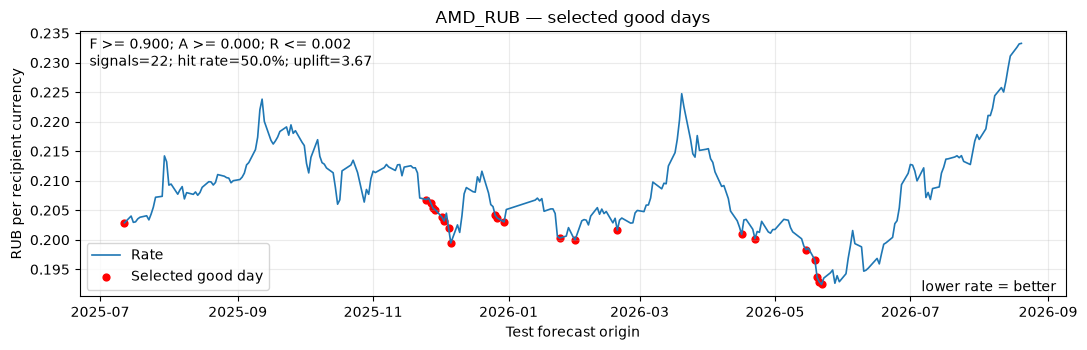

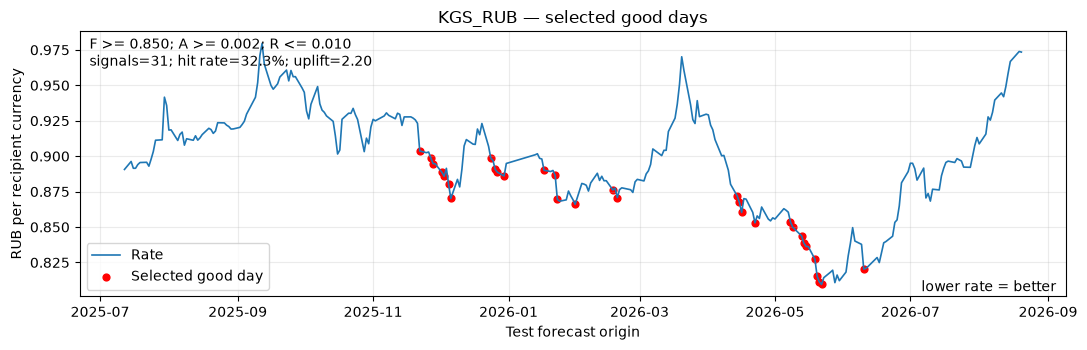

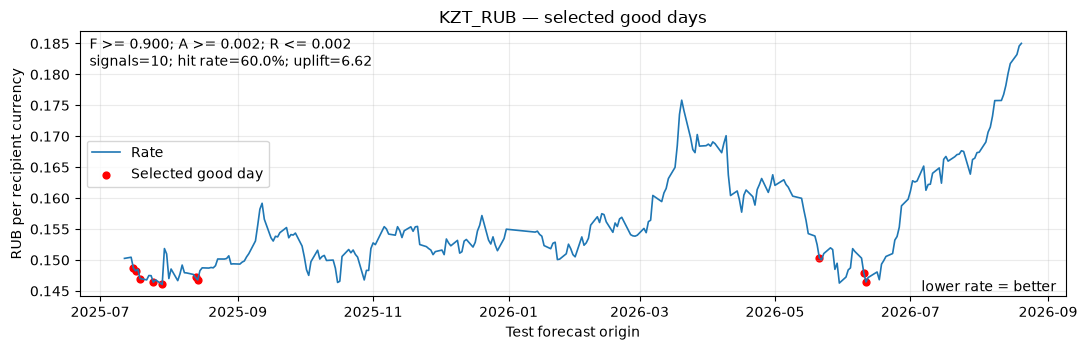

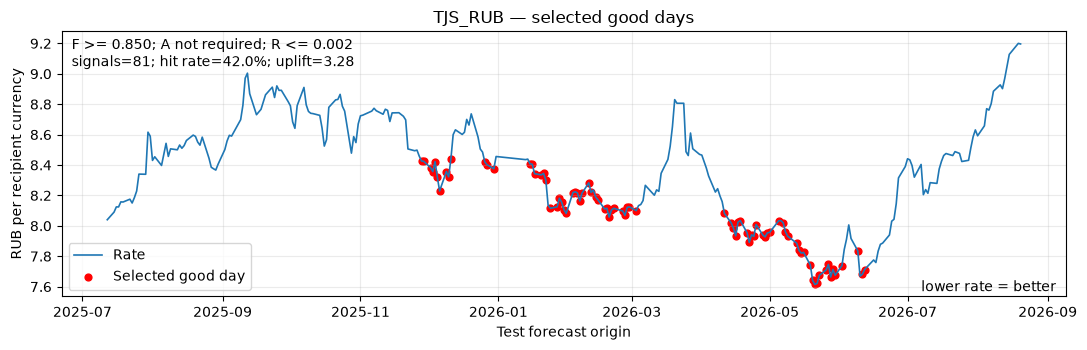

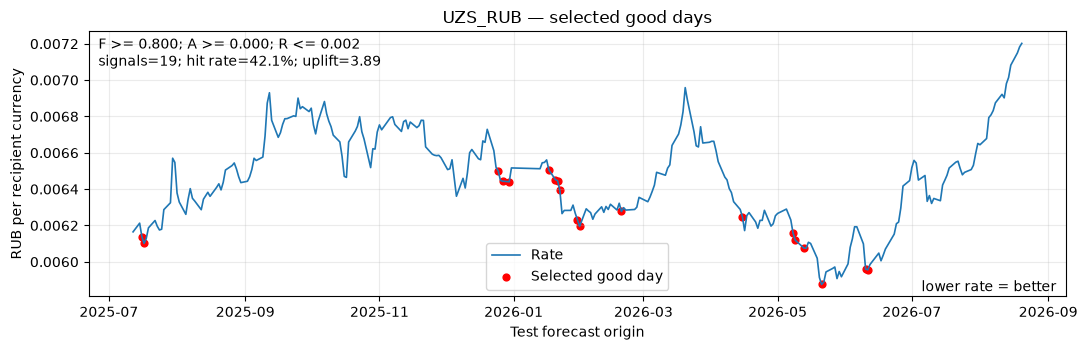

In [6]:
plot_test(run['predictions'], run['selection'], run['test_metrics'], ROOT/'reports/figures/good_day_rules')

## 6. Error analysis

In [7]:
print('До 10 false positives на коридор:')
display(run['false_positives'])
print('До 10 missed GT_B good days на коридор:')
display(run['missed'])

До 10 false positives на коридор:


,corridor,date,rate_t,favourability_percentile_90,past_advantage_5,predicted_regret_5,actual_regret_5
0,AMD_RUB,2026-05-15,0.198326,1.000000,0.003177,0.001047,0.029688
1,AMD_RUB,2025-11-29,0.205092,1.000000,0.001227,0.000644,0.027466
2,AMD_RUB,2025-12-02,0.203842,1.000000,0.006095,0.001398,0.021502
3,AMD_RUB,2026-05-19,0.196581,1.000000,0.008799,0.001838,0.021075
4,AMD_RUB,2025-12-03,0.203187,1.000000,0.003213,0.001227,0.018348
5,AMD_RUB,2025-11-28,0.205344,0.988889,0.004243,0.001456,0.016533
6,AMD_RUB,2025-11-27,0.206219,0.955556,0.002877,0.001340,0.014703
7,AMD_RUB,2025-11-25,0.206814,0.911111,0.001294,0.000888,0.014370
8,AMD_RUB,2025-12-05,0.201949,1.000000,0.006093,0.001885,0.012330
9,AMD_RUB,2026-05-20,0.193619,1.000000,0.015068,0.001888,0.006100


До 10 missed GT_B good days на коридор:


,corridor,date,rate_t,favourability_percentile_90,past_advantage_5,predicted_regret_5,actual_regret_5
0,AMD_RUB,2025-07-16,0.202953,0.966667,-0.000389,0.000982,0.000000
1,AMD_RUB,2025-07-17,0.203038,0.944444,-0.000808,0.000132,0.000000
2,AMD_RUB,2025-12-10,0.201248,0.988889,-0.008969,0.001655,0.000000
3,AMD_RUB,2025-07-23,0.203371,0.911111,-0.002060,0.000233,0.000000
4,AMD_RUB,2025-12-11,0.204022,0.933333,-0.022877,0.000000,0.000000
5,AMD_RUB,2026-02-25,0.202822,0.855556,-0.005927,0.000344,0.000000
6,AMD_RUB,2026-02-06,0.202514,0.888889,-0.012509,0.000924,0.000000
7,AMD_RUB,2026-06-17,0.195918,0.855556,-0.006333,0.001025,0.000000
8,AMD_RUB,2026-06-11,0.194846,0.888889,-0.000827,0.000211,0.000000
9,AMD_RUB,2026-06-12,0.195179,0.866667,-0.002537,0.000430,0.000000


## 7. Leakage check

In [8]:
display(run['leakage'])
leakage_status = 'PASS' if run['leakage'].passed.all() else 'FAIL'
print('STAGE 08 LEAKAGE CHECK:', leakage_status)

,check,passed
0,no test data in threshold selection,True
1,no new CatBoost tuning,True
2,exact Stage-04 configs reused,True
3,restored Stage-04 validation metrics match,True
4,validation models trained on TRAIN only,True
5,validation origins match approved split,True
6,actual regret is labels/evaluation only,True
7,test used only after rule fixation,True
8,rules selected separately per corridor,True


STAGE 08 LEAKAGE CHECK: PASS


## 8. Final summary

In [9]:
final = run['selection'].merge(run['primary'][['corridor','n_signals','signal_frequency','hit_rate','uplift']], on='corridor')
final = final.rename(columns={'selected_rule':'selected_rule','n_signals':'test_signals','signal_frequency':'test_frequency','hit_rate':'test_hit_rate','uplift':'test_uplift'})
display(final[['corridor','selected_rule','test_signals','test_frequency','test_hit_rate','test_uplift','status']])
valid = final.status.eq('VALIDATED_RULE')
print(f'validated rule found: {valid.sum()}/5')
print(f'test uplift > 1: {final.test_uplift.gt(1).sum()}/5')
print(f'test uplift >= 1.3: {final.test_uplift.ge(1.3).sum()}/5')
print('average test uplift:', final.loc[valid,'test_uplift'].mean())
print('Ground truth: GOOD = ATTRACTIVE_NOW AND SAFE_TO_ACT')
print('Main GT: favourability_percentile_90 >= 0.85 AND actual_regret_5 <= 0.005')
print('Leakage:', leakage_status)
for name,path in run['paths'].items(): print(f'{name}: {path.relative_to(ROOT)}')

,corridor,selected_rule,test_signals,test_frequency,test_hit_rate,test_uplift,status
0,AMD_RUB,F=0.900|A=0.000|R=0.002,22,0.080000,0.500000,3.670745,VALIDATED_RULE
1,KGS_RUB,F=0.850|A=0.002|R=0.010,31,0.112727,0.322581,2.201027,VALIDATED_RULE
2,KZT_RUB,F=0.900|A=0.002|R=0.002,10,0.036364,0.600000,6.617647,VALIDATED_RULE
3,TJS_RUB,F=0.850|A=NONE|R=0.002,81,0.294545,0.419753,3.277635,VALIDATED_RULE
4,UZS_RUB,F=0.800|A=0.000|R=0.002,19,0.069091,0.421053,3.889789,VALIDATED_RULE


validated rule found: 5/5
test uplift > 1: 5/5
test uplift >= 1.3: 5/5
average test uplift: 3.9313687483738065
Ground truth: GOOD = ATTRACTIVE_NOW AND SAFE_TO_ACT
Main GT: favourability_percentile_90 >= 0.85 AND actual_regret_5 <= 0.005
Leakage: PASS
validation_predictions: reports\catboost_multihorizon_validation_predictions.csv
validation_features: reports\good_day_features_validation.csv
selection: reports\per_corridor_rule_selection.csv
test_results: reports\per_corridor_good_day_test_results.csv
predictions: reports\per_corridor_good_day_predictions.csv
report: reports\per_corridor_good_day_report.md
